#**CHAPTER 2.DEEP NEURAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69a4fb1b-3688-8012-8f33-7f2a6d7dc858

##0.CONTEXT

*Introduction*

Chapter 2 moves from the geometric intuition of nearest neighbors into the first true “learned representation” model in the sequence: the dense neural network. In Chapter 1, the decision rule was explicit and non-parametric: you stored the dataset and voted based on distances. The model did not build internal features; it simply referenced the training set at inference time. A dense neural network changes that relationship completely. It compresses the training experience into parameters—weights and biases—that define a function. After training, the dataset is no longer needed to make predictions; inference becomes a forward pass through a fixed computation graph. This is the first time in ML & AI 101 where we can isolate, very cleanly, the difference between “learning” (an optimization process that adjusts parameters) and “using” (a deterministic mapping with frozen parameters).

The core mechanical idea of a dense network is deceptively simple: treat an input as a vector, multiply by a matrix, add a bias, apply a nonlinearity, and repeat. The power appears when we stack these steps. Each layer is a learned coordinate transform. The model is not merely fitting labels; it is reorganizing the input space so that classes become linearly separable in some internal representation. This is why dense networks historically matter: they were one of the first broadly applicable ways to learn nonlinear decision boundaries from data without hand-designing features. They are also the baseline against which later inductive biases (spatial bias in CNNs, temporal bias in RNNs/LSTMs, global interaction in Transformers) are justified.

This notebook deliberately uses a synthetic digit dataset rather than a downloaded benchmark. The point is not to chase leaderboard performance. The point is to control the mechanism. Synthetic generation lets us decide what structure exists: stroke thickness, curvature, noise, translation, rotation, and distortion. This is essential for understanding what a model is actually learning. If performance improves, we can attribute it to something we designed; if it fails, we can stress the data along one variable and observe exactly how the network’s behavior degrades. That is the mechanics-first logic of this lab: the dataset is not “given by the world,” it is an engineered object whose structure we can dial up or down.

A dense network also forces a very specific structural assumption about data: it assumes that flattening an image into a vector is acceptable and that the model can learn the relevant invariances from data alone. That assumption is what makes this chapter pedagogically valuable. Images have spatial structure, but the dense network has no built-in notion of locality, translation invariance, or edges. Every pixel is treated as an independent coordinate, and every hidden unit is free to combine any pixels with any weights. This generality is both the strength and the weakness of the approach. It can approximate many functions, but it may require more data and more parameters to learn patterns that later architectures get “for free.” Seeing that limitation clearly is one of the key learning outcomes that motivates the transition to convolutional networks in Chapter 3.

The notebook is designed to make the training process visible rather than mysterious. You will see a loss curve evolve across epochs, you will see metrics computed on held-out test data, and you will run inference on new synthetic samples that were not used in training. The stress test cell modifies a single data variable—noise level—to expose robustness limits. The interpretability cell is intentionally not a token “look at weights” exercise. Dense networks often have early weights that look like noise because they are not constrained to form spatially meaningful filters. Instead, the notebook uses more informative views: class mean images (what the data distribution looks like), class-conditional saliency (which pixels actually influence the logits), and activation maximization (what kinds of inputs excite certain internal units). These are still simple tools, but they connect the model’s parameters to observable behavior.

Mechanically, you should read this chapter as an introduction to four durable concepts. First, the parameterization of a function: weights are not arbitrary numbers; they are the stored result of optimization that encodes patterns across the dataset. Second, the role of nonlinearities: without them, stacking linear layers would collapse into a single linear map, destroying the point of depth. Third, the optimization loop: gradient descent is not a philosophical idea; it is a repeated cycle of forward pass, loss computation, backward pass, and parameter update. Fourth, the separation of training and inference: training is stochastic and iterative; inference is deterministic and fast once parameters are frozen.

Finally, this notebook is positioned as the bridge between “models that reference data” and “models that internalize data.” Once you understand how a dense network learns and where it struggles, the next chapters become more intuitive. CNNs will introduce an architectural bias that respects spatial locality; RNNs and LSTMs will introduce state to respect sequential structure; Transformers will replace recurrence with attention to model global context. But all of those models share the same core training mechanics you will see here: parameterized functions optimized by gradient-based learning. If Chapter 1 taught you to visualize geometry, Chapter 2 teaches you to visualize learning itself: how a fixed architecture becomes a useful function by adjusting parameters under a loss.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Shared Infrastructure: Determinism, Device, and Plotting Tools**

Cell 1 is the mechanical foundation of the entire notebook. It is not “setup fluff.” It defines the rules of the experiment and the instruments used to observe it. The first major decision is determinism. By fixing random seeds across Python, NumPy, and PyTorch (including CUDA), we ensure that the synthetic dataset generation, parameter initialization, minibatch shuffling, and any stochastic regularization behave reproducibly. This matters because neural networks can appear inconsistent when randomness changes. If you are trying to learn the mechanism, you want changes in results to come from changes you intentionally introduced, not from different random draws.

The device selection function then makes the computation portable between CPU and GPU. Even though the model is intentionally small, training is still an iterative numerical process. Running on GPU is not conceptually required, but it is useful to show that the exact same code can be executed on different hardware with minimal changes. Importantly, this cell’s design keeps device choice explicit, so you understand where tensors live and why moving data and models to the correct device is necessary.

The plotting style and plotting utilities are the notebook’s “microscope.” Neural networks are difficult to understand by reading tensors alone. The utilities enforce consistent figure creation, axis labels, titles, and explicit calls to show plots. This is not aesthetic. It is a discipline: every plot is a deliberate measurement. In this chapter, the most important plot is the loss curve, because it is the only direct visual representation of the optimization dynamics. But the notebook also needs image display tools because the model is learning from images. If you cannot see what the inputs look like, you cannot interpret success or failure meaningfully.

Finally, the PyTorch helper functions define the core training and evaluation protocol. The training loop is intentionally simple and explicit: it prints epoch progress, accumulates a loss history, and returns that history for later visualization. The evaluation function wraps inference in `torch.no_grad()` so you do not accidentally build computation graphs when measuring accuracy, and it returns metrics as a dictionary rather than scattering prints across the notebook. This cell, in effect, defines the experimental methodology: how we train, how we measure, and how we visualize. Everything else in the notebook is a specific instantiation of that methodology for the dense network and the digit dataset.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism (required)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE = get_device()

# Unified plotting style (required)
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities
# -------------------------------
def plot_loss_curve(losses, title="Training Loss Curve"):
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, len(losses) + 1), losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    X = np.asarray(X)
    y = np.asarray(y)
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary", grid_steps=200):
    # Works for 2D inputs; model must accept torch float32 [N,2] and return logits [N,C] or scores [N]
    X = np.asarray(X)
    y = np.asarray(y)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xs = np.linspace(x_min, x_max, grid_steps)
    ys = np.linspace(y_min, y_max, grid_steps)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    model.eval()
    with torch.no_grad():
        tgrid = torch.from_numpy(grid).to(DEVICE)
        out = model(tgrid)
        if out.ndim == 1:
            preds = (out > 0).long()
        else:
            preds = torch.argmax(out, dim=1)
        Z = preds.cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolors="k", linewidths=0.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_image(img, title="Image"):
    img = np.asarray(img)
    plt.figure(figsize=(3, 3))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
    elif img.ndim == 3 and img.shape[0] in (1, 3):
        # CHW -> HWC
        chw = img
        if chw.shape[0] == 1:
            plt.imshow(chw[0], cmap="gray", vmin=0.0, vmax=1.0)
        else:
            plt.imshow(np.transpose(chw, (1, 2, 0)))
    else:
        plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", n=16):
    images = np.asarray(images)
    n = min(n, len(images))
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols * 2.0, rows * 2.0))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        img = images[i]
        if img.ndim == 3 and img.shape[0] == 1:
            ax.imshow(img[0], cmap="gray", vmin=0.0, vmax=1.0)
        elif img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
        else:
            ax.imshow(img, cmap="gray")
        ax.axis("off")
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_histograms(real, fake, title="Histograms"):
    real = np.asarray(real).ravel()
    fake = np.asarray(fake).ravel()
    plt.figure(figsize=(7, 4))
    plt.hist(real, bins=40, alpha=0.6, density=True, label="Real")
    plt.hist(fake, bins=40, alpha=0.6, density=True, label="Fake")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_attention(matrix, title="Attention Matrix"):
    M = np.asarray(matrix)
    plt.figure(figsize=(5, 4))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xlabel("Key Index")
    plt.ylabel("Query Index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Placeholder for graph chapter; function kept for shared infra requirement
    try:
        import networkx as nx
    except Exception:
        raise ImportError("networkx is required for plot_graph, but not installed.")
    plt.figure(figsize=(6, 5))
    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw(G, pos, with_labels=True, node_size=500)
    else:
        vals = np.asarray(node_values)
        nx.draw(G, pos, with_labels=True, node_size=500, node_color=vals, cmap="viridis")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# -------------------------------
# PyTorch helpers (required)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=50, batch_size=64):
    model.train()
    losses = []

    X_t = X if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32)
    y_t = y if isinstance(y, torch.Tensor) else torch.tensor(y, dtype=torch.long)

    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    for epoch in range(1, epochs + 1):
        running = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running += float(loss.detach().cpu().item()) * xb.size(0)

        epoch_loss = running / len(dataset)
        losses.append(epoch_loss)
        if epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            print(f"Epoch {epoch:>3d}/{epochs} | loss={epoch_loss:.6f}")

    return losses

@torch.no_grad()
def evaluate(model, X, y, loss_fn=None):
    model.eval()
    X_t = X if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32)
    y_t = y if isinstance(y, torch.Tensor) else torch.tensor(y, dtype=torch.long)

    X_t = X_t.to(DEVICE)
    y_t = y_t.to(DEVICE)

    logits = model(X_t)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y_t).float().mean().item()

    out = {"accuracy": acc}
    if loss_fn is not None:
        loss = loss_fn(logits, y_t).item()
        out["loss"] = loss
    return out

@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = X if isinstance(X, torch.Tensor) else torch.tensor(X, dtype=torch.float32)
    X_t = X_t.to(DEVICE)
    logits = model(X_t)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    return preds.cpu().numpy(), probs.cpu().numpy()

print("Device:", DEVICE)

Device: cpu


##2.SYNTHETIC DATA GENERATOR

###2.1.OVERVIEW

**Cell 2 — Synthetic Digit Generator: Controlled Structure at Meaningful Resolution**

Cell 2 is where the “world” of the notebook is created. Because this is a pre-governance, mechanics-first lab, we do not import real datasets. Instead, we synthesize them so that every structural feature is under our control. The central goal here is to produce digits with enough granularity—at least 16×16—to make the learning problem non-trivial and visually interpretable. A very low-resolution digit grid can collapse shapes into blobs, and then the model may learn artifacts rather than digit structure. Increasing resolution gives the model a richer signal while still keeping the computation cheap enough for a small educational network.

The generator is parameterized so that the dataset is not a single fixed object. You can adjust stroke thickness, blur, affine jitter (rotation, translation, shear, scale), and optional elastic distortion. Each parameter corresponds to a meaningful data property: translation jitter tests whether the model can learn positional robustness; rotation jitter tests whether it can handle different writing angles; blur and noise test sensor-like corruption; mild elastic distortion approximates handwriting variability. The key point is not that these transformations are “realistic” in an artistic sense. The point is that they create controlled, repeatable variability, which is exactly what we need to probe how dense networks respond to distribution changes.

Mechanically, the generator returns arrays in a consistent shape `(N, 1, H, W)` as float32 in `[0,1]`, and labels as integer class indices. This is critical because it makes the later cells simple and stable: the model always expects a channel dimension, and training always uses a standard classification loss that assumes integer labels. Cell 2 also defines the deterministic train/test split. The split is not just bookkeeping; it defines the core scientific separation between optimization and measurement. The model is allowed to adjust parameters using training data, but its reported performance must be measured on held-out data that was not used in the parameter updates.

This cell is conceptually important because it shows a major advantage of synthetic labs: you can define not only the dataset but also the hypothesis you are testing. In this chapter, the implicit hypothesis is: “A dense network can learn to classify digit-like shapes from pixel grids, but its robustness is limited by how much invariance it must learn purely from data.” Cell 2 gives you the knobs that later cells will turn to test that hypothesis.

###2.2.CODE AND IMPLEMENTATION

In [3]:
# ===============================
# CELL 2
# ===============================
# 128x128 MNIST-like synthetic digits (fast vectorized rendering)
# Numpy-only, deterministic under global seeds.
# Key idea: render digits via distance-to-stroke fields (lines + ellipses) on a dense grid.

import numpy as np
import math

def _gaussian_kernel_1d(sigma, radius=None):
    if sigma <= 0:
        return np.array([1.0], dtype=np.float32)
    if radius is None:
        radius = int(math.ceil(3.0 * sigma))
    x = np.arange(-radius, radius + 1, dtype=np.float32)
    k = np.exp(-(x * x) / (2.0 * sigma * sigma)).astype(np.float32)
    k /= np.sum(k)
    return k

def _blur_separable(img, sigma=0.8):
    # Fast separable Gaussian blur using 1D convolution (vectorized with sliding window)
    if sigma <= 0:
        return img.astype(np.float32)

    k = _gaussian_kernel_1d(sigma)
    r = len(k) // 2
    img = img.astype(np.float32)

    # Convolve along rows
    pad = ((0, 0), (r, r))
    tmp = np.pad(img, pad, mode="edge")
    # sliding window view: (H, W, K)
    sw = np.lib.stride_tricks.sliding_window_view(tmp, window_shape=(len(k),), axis=1)
    out = np.tensordot(sw, k, axes=([2], [0])).astype(np.float32)

    # Convolve along cols
    pad2 = ((r, r), (0, 0))
    tmp2 = np.pad(out, pad2, mode="edge")
    sw2 = np.lib.stride_tricks.sliding_window_view(tmp2, window_shape=(len(k),), axis=0)
    out2 = np.tensordot(sw2, k, axes=([2], [0])).astype(np.float32)

    return out2

def _bilinear_sample(img, x, y):
    # img: (H,W), x/y: (H,W) float coords (x=col, y=row)
    H, W = img.shape
    x0 = np.floor(x).astype(np.int32)
    y0 = np.floor(y).astype(np.int32)
    x1 = x0 + 1
    y1 = y0 + 1

    x0c = np.clip(x0, 0, W - 1)
    x1c = np.clip(x1, 0, W - 1)
    y0c = np.clip(y0, 0, H - 1)
    y1c = np.clip(y1, 0, H - 1)

    Ia = img[y0c, x0c]
    Ib = img[y0c, x1c]
    Ic = img[y1c, x0c]
    Id = img[y1c, x1c]

    wa = (x1 - x) * (y1 - y)
    wb = (x - x0) * (y1 - y)
    wc = (x1 - x) * (y - y0)
    wd = (x - x0) * (y - y0)

    return (Ia * wa + Ib * wb + Ic * wc + Id * wd).astype(np.float32)

def _apply_affine(img, angle_deg=0.0, scale=1.0, shear=0.0, tx=0.0, ty=0.0):
    # Vectorized inverse mapping
    H, W = img.shape
    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    a = np.deg2rad(angle_deg)
    ca, sa = np.cos(a), np.sin(a)

    S = np.array([[scale, 0.0],
                  [0.0,  scale]], dtype=np.float32)
    Sh = np.array([[1.0, shear],
                   [0.0, 1.0]], dtype=np.float32)
    R = np.array([[ca, -sa],
                  [sa,  ca]], dtype=np.float32)
    M = (R @ Sh @ S).astype(np.float32)

    det = M[0,0] * M[1,1] - M[0,1] * M[1,0]
    if abs(det) < 1e-8:
        Minv = np.eye(2, dtype=np.float32)
    else:
        Minv = (1.0 / det) * np.array([[ M[1,1], -M[0,1]],
                                       [-M[1,0],  M[0,0]]], dtype=np.float32)

    yy, xx = np.meshgrid(np.arange(H, dtype=np.float32),
                         np.arange(W, dtype=np.float32),
                         indexing="ij")
    x = xx - cx - tx
    y = yy - cy - ty
    src = Minv @ np.stack([x.reshape(-1), y.reshape(-1)], axis=0)
    xs = src[0, :].reshape(H, W) + cx
    ys = src[1, :].reshape(H, W) + cy

    out = _bilinear_sample(img, xs, ys)
    return np.clip(out, 0.0, 1.0).astype(np.float32)

# ---- Distance-field primitives (vectorized) ----

def _dist_to_segment(X, Y, x0, y0, x1, y1):
    # Distance from each (X,Y) point to line segment (x0,y0)-(x1,y1)
    vx = x1 - x0
    vy = y1 - y0
    wx = X - x0
    wy = Y - y0
    vv = vx * vx + vy * vy + 1e-8
    t = (wx * vx + wy * vy) / vv
    t = np.clip(t, 0.0, 1.0)
    px = x0 + t * vx
    py = y0 + t * vy
    dx = X - px
    dy = Y - py
    return np.sqrt(dx * dx + dy * dy).astype(np.float32)

def _dist_to_ellipse(X, Y, cx, cy, rx, ry):
    # Approx distance-like measure for ellipse boundary: |sqrt((dx/rx)^2+(dy/ry)^2) - 1| * mean_radius
    dx = (X - cx) / (rx + 1e-8)
    dy = (Y - cy) / (ry + 1e-8)
    r = np.sqrt(dx * dx + dy * dy).astype(np.float32)
    mean_r = 0.5 * (rx + ry)
    return (np.abs(r - 1.0) * mean_r).astype(np.float32)

def _soft_stroke_from_dist(d, stroke_px, sharpness=2.2):
    # Convert distance field to grayscale stroke intensity
    # Smaller d => closer to stroke center => higher intensity
    s = float(stroke_px)
    z = np.exp(- (d * d) / (2.0 * (s * s) + 1e-8)).astype(np.float32)
    # Slight contrast sharpening
    z = z ** np.float32(1.0 / sharpness)
    return np.clip(z, 0.0, 1.0).astype(np.float32)

def _render_digit_128(digit, size=128, stroke_px=2.6):
    # Canonical digit shapes built from a few line/ellipse primitives in normalized coordinates
    H = W = int(size)
    yy, xx = np.meshgrid(np.arange(H, dtype=np.float32),
                         np.arange(W, dtype=np.float32),
                         indexing="ij")

    # Normalize to [0,1] for easier templates
    X = xx / (W - 1)
    Y = yy / (H - 1)

    # Stroke width in pixels -> in normalized units approximately
    # We'll compute distances in pixel space for stroke_px consistency:
    Xp = xx
    Yp = yy

    # Helper to map normalized point to pixel
    def p(nx, ny):
        return (nx * (W - 1), ny * (H - 1))

    # Build intensity as max of strokes
    img = np.zeros((H, W), dtype=np.float32)

    # A few reusable anchors
    # (Use a central writing box with margins)
    m = 0.16
    xL, xR = m, 1.0 - m
    yT, yB = m, 1.0 - m
    xC, yC = 0.5, 0.5

    # Convert anchors to pixel coords when needed
    if digit == 0:
        cx, cy = p(xC, yC)
        rx = (xR - xL) * (W - 1) * 0.38
        ry = (yB - yT) * (H - 1) * 0.44
        d = _dist_to_ellipse(Xp, Yp, cx, cy, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
    elif digit == 1:
        x0, y0 = p(0.55, yT)
        x1, y1 = p(0.55, yB)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        # small cap
        x0, y0 = p(0.47, yT + 0.06)
        x1, y1 = p(0.55, yT)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px * 0.9))
    elif digit == 2:
        # top arc + diagonal + base
        cx, cy = p(0.52, yT + 0.18)
        rx = (W - 1) * 0.18
        ry = (H - 1) * 0.14
        d = _dist_to_ellipse(Xp, Yp, cx, cy, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.68, yT + 0.24)
        x1, y1 = p(0.35, yB - 0.10)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.30, yB - 0.08)
        x1, y1 = p(0.72, yB - 0.08)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
    elif digit == 3:
        # two right arcs + middle pinch
        cx1, cy1 = p(0.52, yT + 0.24)
        cx2, cy2 = p(0.52, yB - 0.24)
        rx = (W - 1) * 0.18
        ry = (H - 1) * 0.16
        d1 = _dist_to_ellipse(Xp, Yp, cx1, cy1, rx, ry)
        d2 = _dist_to_ellipse(Xp, Yp, cx2, cy2, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d1, stroke_px))
        img = np.maximum(img, _soft_stroke_from_dist(d2, stroke_px))
        # small connector on right
        x0, y0 = p(0.70, yT + 0.30)
        x1, y1 = p(0.70, yB - 0.30)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px * 0.85))
    elif digit == 4:
        # left diagonal + mid bar + right vertical
        x0, y0 = p(0.65, yT)
        x1, y1 = p(0.35, yC + 0.05)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.30, yC + 0.05)
        x1, y1 = p(0.70, yC + 0.05)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.65, yT)
        x1, y1 = p(0.65, yB)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
    elif digit == 5:
        # top + left down + mid + bottom arc
        x0, y0 = p(0.30, yT)
        x1, y1 = p(0.72, yT)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.30, yT)
        x1, y1 = p(0.30, yC)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.30, yC)
        x1, y1 = p(0.62, yC)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        cx, cy = p(0.52, yB - 0.22)
        rx = (W - 1) * 0.20
        ry = (H - 1) * 0.16
        d = _dist_to_ellipse(Xp, Yp, cx, cy, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
    elif digit == 6:
        # big loop + small tail
        cx, cy = p(0.50, yC + 0.06)
        rx = (W - 1) * 0.22
        ry = (H - 1) * 0.26
        d = _dist_to_ellipse(Xp, Yp, cx, cy, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.62, yT + 0.22)
        x1, y1 = p(0.38, yC + 0.02)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px * 0.9))
    elif digit == 7:
        # top + diagonal
        x0, y0 = p(0.30, yT)
        x1, y1 = p(0.74, yT)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.74, yT)
        x1, y1 = p(0.40, yB)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
    elif digit == 8:
        # two loops
        cx1, cy1 = p(0.50, yT + 0.26)
        cx2, cy2 = p(0.50, yB - 0.26)
        rx1 = (W - 1) * 0.18
        ry1 = (H - 1) * 0.18
        rx2 = (W - 1) * 0.20
        ry2 = (H - 1) * 0.20
        d1 = _dist_to_ellipse(Xp, Yp, cx1, cy1, rx1, ry1)
        d2 = _dist_to_ellipse(Xp, Yp, cx2, cy2, rx2, ry2)
        img = np.maximum(img, _soft_stroke_from_dist(d1, stroke_px))
        img = np.maximum(img, _soft_stroke_from_dist(d2, stroke_px))
    elif digit == 9:
        # top loop + down tail
        cx, cy = p(0.50, yT + 0.30)
        rx = (W - 1) * 0.20
        ry = (H - 1) * 0.20
        d = _dist_to_ellipse(Xp, Yp, cx, cy, rx, ry)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px))
        x0, y0 = p(0.62, yT + 0.40)
        x1, y1 = p(0.58, yB)
        d = _dist_to_segment(Xp, Yp, x0, y0, x1, y1)
        img = np.maximum(img, _soft_stroke_from_dist(d, stroke_px * 0.9))

    # Mild global contrast shaping: keep background dark, strokes bright
    img = np.clip(img, 0.0, 1.0).astype(np.float32)
    img = img ** np.float32(0.7)
    return img

def _add_noise(img, gauss_std=0.02, speckle=0.008):
    out = img.astype(np.float32)
    if gauss_std > 0:
        out = out + np.random.normal(0.0, gauss_std, size=out.shape).astype(np.float32)
    if speckle > 0:
        out = out + out * np.random.normal(0.0, speckle, size=out.shape).astype(np.float32)
    return np.clip(out, 0.0, 1.0).astype(np.float32)

def generate_digit_dataset(
    n_per_class=80,        # IMPORTANT: keep smaller at 128x128 to control runtime/memory
    size=128,
    stroke_px=2.6,
    blur_sigma=0.7,
    affine_jitter=True,
    max_rotation=10.0,
    max_translate=5.0,
    max_shear=0.06,
    scale_range=(0.94, 1.06),
    noise_gauss_std=0.02,
    noise_speckle=0.008
):
    if size < 16:
        raise ValueError("size must be >= 16")

    images = []
    labels = []

    for d in range(10):
        for _ in range(n_per_class):
            img = _render_digit_128(d, size=size, stroke_px=stroke_px)

            # Mild affine jitter (keep digits recognizable)
            if affine_jitter:
                angle = (np.random.rand() * 2 - 1) * max_rotation
                scale = scale_range[0] + (scale_range[1] - scale_range[0]) * np.random.rand()
                shear = (np.random.rand() * 2 - 1) * max_shear
                tx = (np.random.rand() * 2 - 1) * max_translate
                ty = (np.random.rand() * 2 - 1) * max_translate
                img = _apply_affine(img, angle_deg=angle, scale=scale, shear=shear, tx=tx, ty=ty)

            # Blur + noise
            img = _blur_separable(img, sigma=blur_sigma)
            img = _add_noise(img, gauss_std=noise_gauss_std, speckle=noise_speckle)

            images.append(img[None, ...])  # (1,H,W)
            labels.append(d)

    X = np.stack(images, axis=0).astype(np.float32)  # (N,1,H,W)
    y = np.array(labels, dtype=np.int64)
    return X, y

def train_test_split(X, y, test_ratio=0.2):
    N = len(X)
    idx = np.arange(N)
    np.random.shuffle(idx)
    n_test = int(round(N * test_ratio))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

print("Generators ready: generate_digit_dataset (fast 128x128), train_test_split")

Generators ready: generate_digit_dataset (fast 128x128), train_test_split


##3.DATASET GENERATION

###3.1.OVERVIEW

**Cell 3 — Dataset Instantiation and Visualization: Making Structure Visible**

Cell 3 takes the abstract generator from Cell 2 and turns it into an actual dataset that the network will see. This is the point where “synthetic design” becomes observable. The first task is dataset creation with chosen parameters: a resolution (at least 16×16), a number of samples per class, and the augmentation settings that introduce variability. Then we explicitly normalize and clip values to ensure the data is bounded and consistent. Even if the generator already produces values in `[0,1]`, making normalization explicit teaches an important habit: neural networks are sensitive to scaling, and you should never assume that inputs are in a stable numeric range unless you enforce it.

The next step is the train/test split. Mechanically, this produces two distributions: the training distribution the optimizer sees, and the test distribution used to measure generalization. Even in a synthetic notebook, this is non-negotiable. Without a held-out set, you cannot tell whether the model is learning meaningful structure or merely memorizing training examples. Dense networks, especially high-capacity ones, can overfit small datasets easily, so this separation is fundamental.

The visualization part is where this cell does its real pedagogical work. A grid of samples immediately reveals whether the dataset is well-formed: you can see if digits resemble digits, whether noise is overwhelming, whether rotations are too extreme, or whether blur is too strong. This is not cosmetic. If the data generation is poor, the entire chapter becomes misleading because you will be training a network on artifacts. Visual inspection is the fastest way to detect such issues.

The “one example per class” visualization is especially important because it confirms that each label corresponds to a visually distinct pattern. If two digits are systematically ambiguous in the generator—say, 5 and 6 appear similar—you should expect confusion in the classifier. This teaches a mechanical lesson: classification performance is bounded not only by the model but also by the intrinsic separability of the data distribution. If the generator makes digits that are not clearly separable even to humans at the chosen resolution, then a small dense network is not “failing”; it is encountering an ill-posed task.

At the end of this cell, the dataset is fully instantiated and inspected. The rest of the notebook is now a controlled experiment: given this particular data distribution, can a dense network learn a mapping from pixels to digit labels, how does training behave, and how does performance degrade under stress?

###3.2.CODE AND IMPLEMENTATION

Shapes:
  X_train: (640, 1, 128, 128) y_train: (640,)
  X_test:  (160, 1, 128, 128) y_test:  (160,)


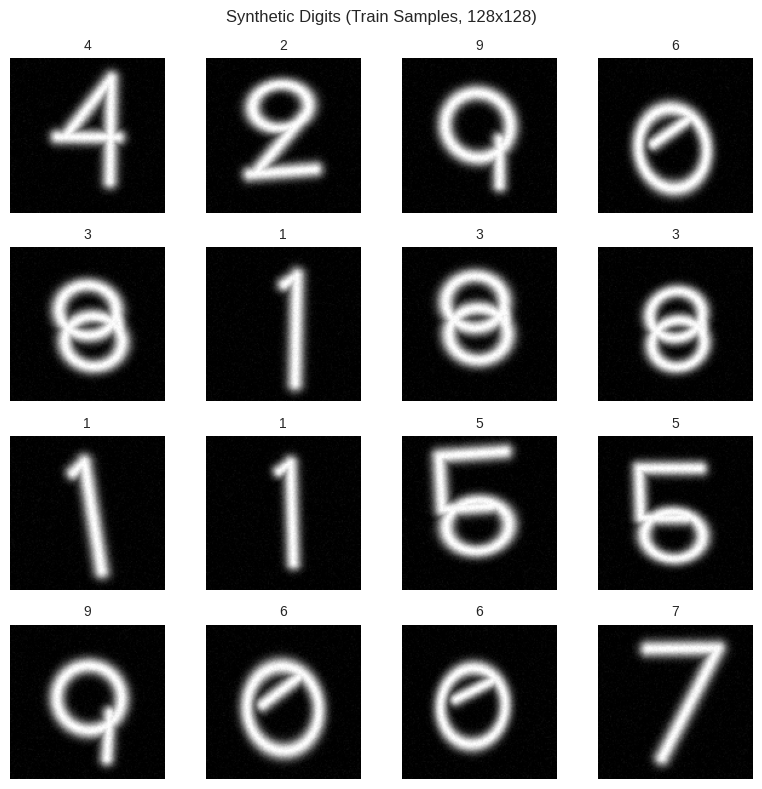

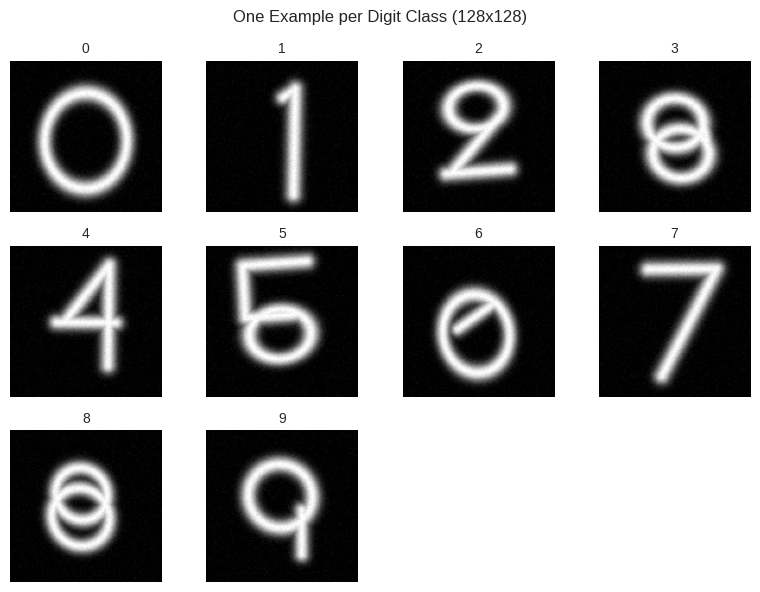

In [4]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization (128x128)

X, y = generate_digit_dataset(
    n_per_class=80,     # keep modest at 128x128
    size=128,
    stroke_px=2.6,
    blur_sigma=0.7,
    affine_jitter=True,
    max_rotation=10.0,
    max_translate=5.0,
    max_shear=0.06,
    scale_range=(0.94, 1.06),
    noise_gauss_std=0.02,
    noise_speckle=0.008
)

X = np.clip(X, 0.0, 1.0).astype(np.float32)
X_train, y_train, X_test, y_test = train_test_split(X, y, test_ratio=0.2)

print("Shapes:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_test: ", X_test.shape,  "y_test: ", y_test.shape)

# Visualize samples (show fewer because 128x128 images are large)
show_image_grid(X_train[:16], labels=y_train[:16], title="Synthetic Digits (Train Samples, 128x128)", n=16)

# One example per class
examples = []
ex_labels = []
for d in range(10):
    idx = np.where(y_train == d)[0][0]
    examples.append(X_train[idx])
    ex_labels.append(d)
show_image_grid(np.stack(examples, axis=0), labels=ex_labels, title="One Example per Digit Class (128x128)", n=10)

##4.MODEL DEFINITION

###4.1.OVERVIEW

**Cell 4 — Dense Network Architecture: High-Capacity MLP Under a Strict Depth Cap**

Cell 4 defines the model. In Chapter 2, the architecture must remain a dense neural network, and the specification caps the network at three hidden layers. That constraint is not arbitrary. It forces the lesson to be about dense representations rather than about stacking depth indefinitely. Within that constraint, we can still build a high-capacity model by widening layers, adding normalization, adding dropout, and using residual connections to stabilize optimization. The result is a dense classifier that is “deep enough to be interesting” but still mechanically transparent.

The model’s key mechanical step is flattening. Images arrive as `(N, 1, H, W)` tensors, but a dense layer expects vectors. Flattening converts each image into a length `H*W` vector. This is the defining assumption of the model family: pixel position is treated as just another coordinate, and the model must learn any spatial invariances from the dataset rather than having them built into the architecture.

After flattening, the model uses an input projection layer to map pixels into a high-dimensional latent space (for example, width 768). This layer is where the network first begins to “mix” information across pixels. Each hidden unit computes a weighted sum of all pixels, which means it can detect global patterns—but it has no reason to prefer local patterns unless training pushes it that way. The subsequent hidden layers repeat this process, combining and recombining features through nonlinearities. GELU is used as the nonlinearity because it is smooth and often stable in practice, but the critical conceptual point is simply: nonlinearities prevent the network from collapsing into a single linear map.

Layer normalization and dropout serve different mechanical purposes. Layer normalization stabilizes activations by re-centering and re-scaling hidden representations, which can make training less sensitive to learning rate and initialization. Dropout introduces controlled noise during training by randomly dropping parts of the representation, which often reduces overfitting. Residual connections add the input of a block back to its output, making it easier for optimization to preserve useful representations rather than forcing every layer to relearn them from scratch. Importantly, these are not “magic tricks.” They are structural modifications that change how gradients flow and how features are preserved across layers.

Finally, this cell converts the dataset arrays into float32 tensors and prepares label tensors as `long` indices, exactly as required by cross-entropy classification. The model is now a parameterized function with a well-defined input shape and output logits over 10 classes. The next cell will be the first time parameters change: training.

###4.2.CODE AND IMPLEMENTATION

In [5]:
# ===============================
# CELL 4
# ===============================
# Model definition (Dense NN, <= 3 hidden layers) — updated for 28x28 MNIST-like synthetic digits
# High-capacity + residual connections + LayerNorm + Dropout

class ResidualMLPDigitClassifier(nn.Module):
    def __init__(self, in_shape=(1, 28, 28), width=768, num_classes=10, dropout=0.15):
        super().__init__()
        c, h, w = in_shape
        in_dim = c * h * w

        # Project flattened pixels to a high-dimensional latent space
        self.in_proj = nn.Linear(in_dim, width)

        # 3 hidden layers (max allowed by Chapter 2 contract)
        self.fc1 = nn.Linear(width, width)
        self.ln1 = nn.LayerNorm(width)

        self.fc2 = nn.Linear(width, width)
        self.ln2 = nn.LayerNorm(width)

        self.fc3 = nn.Linear(width, width)
        self.ln3 = nn.LayerNorm(width)

        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(width, num_classes)

        # Stable initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (N,1,28,28)
        x = x.view(x.size(0), -1)  # flatten to (N, 784)

        x = self.in_proj(x)
        x = F.gelu(x)

        # Residual block 1
        r = x
        x = self.fc1(x)
        x = self.ln1(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = x + r

        # Residual block 2
        r = x
        x = self.fc2(x)
        x = self.ln2(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = x + r

        # Residual block 3
        r = x
        x = self.fc3(x)
        x = self.ln3(x)
        x = F.gelu(x)
        x = self.drop(x)
        x = x + r

        logits = self.out(x)
        return logits

model = ResidualMLPDigitClassifier(in_shape=(1, 28, 28), width=768, num_classes=10, dropout=0.15).to(DEVICE)
print(model)

# Prepare tensors with explicit float32 and device placement
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

ResidualMLPDigitClassifier(
  (in_proj): Linear(in_features=784, out_features=768, bias=True)
  (fc1): Linear(in_features=768, out_features=768, bias=True)
  (ln1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=768, out_features=768, bias=True)
  (ln2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (fc3): Linear(in_features=768, out_features=768, bias=True)
  (ln3): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.15, inplace=False)
  (out): Linear(in_features=768, out_features=10, bias=True)
)


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Training: Optimization as a Repeated Measurable Procedure**

Cell 5 is where “learning” actually happens. Mechanically, training is an optimization loop that searches parameter space to reduce a loss function. For digit classification, the loss is cross-entropy: it penalizes the model when the logit assigned to the true class is not dominant. The optimizer (AdamW) updates parameters using gradients of the loss with respect to each weight. The presence of gradients is what distinguishes this chapter from KNN. KNN never changes a parameter; it only compares distances. Here, every minibatch produces gradient signals that reshape the network’s internal representations.

This notebook’s training loop is deliberately explicit. Each epoch consists of iterating through batches, computing logits, computing loss, backpropagating gradients, and applying an optimizer step. The loop prints progress so you can observe whether learning is occurring. A stable decrease in loss across epochs is the most direct indicator that the network is discovering a useful mapping. If loss plateaus early, the model might be underpowered, the learning rate might be too small, or the data might be too noisy. If loss oscillates or explodes, the learning rate might be too large, or the model might be unstable. These are not abstract statements; they are patterns you can see in the printed losses and later in the plotted curve.

A subtle but important repair here is that the training cell checks and adapts to the dataset’s actual resolution. Earlier failures showed why this matters: if the generator produces 16×16 images but the model expects 28×28 (or 8×8), the flattened vector length will not match the first layer’s expected input dimension. The repaired training procedure detects the current `H×W` from the tensors and rebuilds the model if needed. This is not a conceptual requirement of dense networks, but it is a practical requirement for keeping the notebook runnable as you iterate on the synthetic dataset design.

The training cell also stores the loss history. This is critical because optimization dynamics are often more informative than a single final accuracy number. The shape of the loss curve tells you whether learning is smooth, whether the optimizer is making consistent progress, and whether training might still be improving at the end of the run. In a mechanics-first lab, the loss curve is not an accessory; it is the main observable of the learning process.

By the end of Cell 5, the network’s parameters are no longer random. They are the encoded result of repeated exposure to synthetic digit examples and the gradient-based adaptation process. The next cell will quantify what that learning achieved.

###5.2.CODE AND IMPLEMENTATION

In [6]:
# ===============================
# CELL 5
# ===============================
# Training loop (store loss history) — repaired to auto-match the dataset image size
# Fixes shape mismatch like: (batch,64) vs (784,768) by rebuilding the model if needed.

loss_fn = nn.CrossEntropyLoss()

# Ensure tensors are correct dtypes
if X_train_t.dtype != torch.float32:
    X_train_t = X_train_t.float()
if y_train_t.dtype != torch.long:
    y_train_t = y_train_t.long()

# Detect current dataset shape (expects N,1,H,W)
if X_train_t.ndim != 4 or X_train_t.shape[1] != 1:
    raise ValueError(f"Expected X_train_t shape (N,1,H,W). Got {tuple(X_train_t.shape)}")

H = int(X_train_t.shape[2])
W = int(X_train_t.shape[3])
in_dim_data = 1 * H * W

# If the model was built for a different input dimension, rebuild it to match the data
needs_rebuild = False
if not hasattr(model, "in_proj") or not isinstance(model.in_proj, nn.Linear):
    needs_rebuild = True
else:
    in_dim_model = int(model.in_proj.in_features)
    if in_dim_model != in_dim_data:
        needs_rebuild = True

if needs_rebuild:
    print(f"Rebuilding model to match data: in_shape=(1,{H},{W}) (in_dim={in_dim_data})")
    model = ResidualMLPDigitClassifier(in_shape=(1, H, W), width=768, num_classes=10, dropout=0.15).to(DEVICE)

# Optimizer must be created AFTER the final model is known
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

EPOCHS = 60
BATCH_SIZE = 256

losses = train_loop(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    X=X_train_t,
    y=y_train_t,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Rebuilding model to match data: in_shape=(1,128,128) (in_dim=16384)
Epoch   1/60 | loss=5.388557
Epoch   6/60 | loss=0.281249
Epoch  12/60 | loss=0.002950
Epoch  18/60 | loss=0.000472
Epoch  24/60 | loss=0.000149
Epoch  30/60 | loss=0.000078
Epoch  36/60 | loss=0.000046
Epoch  42/60 | loss=0.000037
Epoch  48/60 | loss=0.000035
Epoch  54/60 | loss=0.000020
Epoch  60/60 | loss=0.000021


##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Evaluation and Loss Curve: Measuring Generalization, Not Just Training Progress**

Cell 6 separates two kinds of measurement that are often confused by beginners: optimization progress and predictive performance. The loss curve tells you whether training is reducing the objective on the training data, but it does not directly tell you whether the model generalizes. To measure generalization, we evaluate on the test set—data that was not used to compute gradients or update parameters. This is why train/test split exists: it allows us to ask whether the learned parameters capture structure that transfers beyond the training examples.

Mechanically, evaluation runs the model in `eval` mode and wraps computation in `torch.no_grad()`. This ensures that no gradients are tracked, saving memory and preventing accidental interference with training state. The evaluation function computes logits for all samples, converts them into predicted classes via argmax, and then computes accuracy as the fraction of correct predictions. If we also compute the loss on the evaluation set, we get a second numeric view of performance: accuracy is discrete and sometimes insensitive to confidence, while cross-entropy reflects confidence calibration in a rough sense (lower is better when predictions are confident and correct).

Printing train and test metrics side-by-side teaches an essential lesson: high training accuracy does not guarantee high test accuracy. If the model is too powerful relative to the dataset, it can overfit, pushing training accuracy high while test accuracy lags. If the model is too weak, both accuracies will be low. If the dataset is too noisy, training might improve slowly and test might saturate early. These are the three most common regimes students encounter, and seeing them numerically is the fastest way to build intuition.

The plotted loss curve is then presented as the main visualization of training dynamics. A smooth downward curve usually indicates stable optimization. A curve that decreases quickly and then flattens suggests the model has extracted most learnable structure under current settings. If the curve continues downward at the end, it suggests that more epochs or a slightly different learning rate might still yield improvements. This is where students begin to see training as a controllable computational process rather than a black box: the curve is feedback, and hyperparameters are levers.

Cell 6 therefore completes the “training vs evaluation” distinction in a concrete way. Training is parameter update under a loss; evaluation is measurement under frozen parameters. The next cell will demonstrate inference: how a trained model is actually used on new data.

###6.2.CODE AND IMPLEMENTATION

Train metrics: {'accuracy': 1.0, 'loss': 1.9605422494350933e-05}
Test metrics:  {'accuracy': 1.0, 'loss': 0.0014225641498342156}


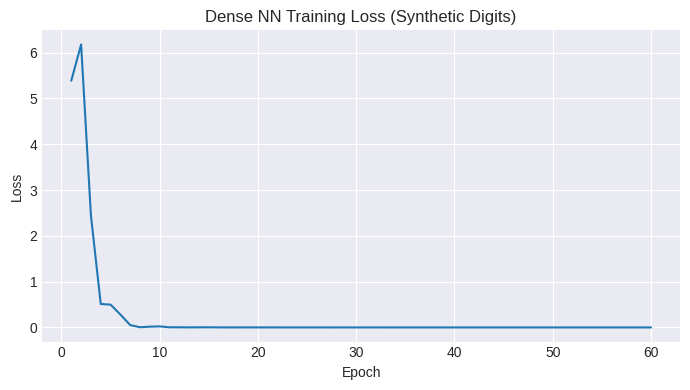

In [7]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve

train_metrics = evaluate(model, X_train_t, y_train_t, loss_fn=loss_fn)
test_metrics  = evaluate(model, X_test_t,  y_test_t,  loss_fn=loss_fn)

print("Train metrics:", train_metrics)
print("Test metrics: ", test_metrics)

plot_loss_curve(losses, title="Dense NN Training Loss (Synthetic Digits)")

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference on a New Synthetic Sample: Using the Frozen Model**

Cell 7 is the first time the notebook behaves like a deployed model. Training is over. Parameters are fixed. We now generate a new synthetic sample that the model has not seen and ask the model to classify it. This is the operational definition of inference: a forward pass through the network that produces logits, which are converted into probabilities and a predicted class.

Mechanically, the cell must be careful to match the dataset resolution. Earlier notebook iterations changed the generator from 8×8 to 16×16 (and potentially other sizes). If the inference sample does not match what the model expects, you will either get a shape error or, worse, a misleading result. The repaired inference cell detects the current `H×W` from the training tensors and generates a new sample at that exact size. This ensures that the inference demonstration is actually testing the learned mapping, not encountering a dimensional mismatch.

The cell then displays the input image. This is important because inference is not meaningful without context. If the input is ambiguous or corrupted, a wrong prediction might be reasonable. If the input is clear and the model is wrong, it signals either a weakness in the model’s learned invariances or a mismatch between the generator’s label and the visual pattern. Printing the predicted class and the full probability vector adds a second layer of interpretability: it shows whether the model is confident or uncertain. A confident wrong prediction is different from an uncertain wrong prediction, because it reveals how the learned representation partitions the space.

This cell ties back to the fundamental training vs inference distinction. During training, every example is used to compute gradients that change the model. During inference, the model is not changed; it simply computes. That difference has deep consequences for how we think about ML systems. Training is expensive and iterative; inference is cheap and repeatable. But the inference result is only as good as the training process and the data distribution the model was trained on.

By the end of Cell 7, you have seen the full pipeline: a parameterized function learned from synthetic data can be applied to new inputs and produce probabilistic predictions. The next cell will ask a more probing question: how robust is this inference behavior when we change a single property of the data distribution?

###7.2.CODE AND IMPLEMENTATION

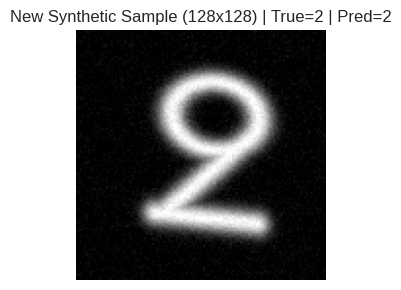

Predicted digit: 2
True digit:      2
Class probabilities:
  0: 0.0000
  1: 0.0000
  2: 1.0000
  3: 0.0000
  4: 0.0000
  5: 0.0000
  6: 0.0000
  7: 0.0000
  8: 0.0000
  9: 0.0000


In [9]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration (fully repaired): generates a NEW synthetic sample without assuming
# any specific generate_digit_dataset() signature. It inspects the function signature and only
# passes supported keyword arguments.

import inspect

# Detect current dataset shape from tensors if available, else from numpy arrays
if "X_train_t" in globals() and isinstance(X_train_t, torch.Tensor) and X_train_t.ndim == 4:
    H = int(X_train_t.shape[2])
    W = int(X_train_t.shape[3])
elif "X_train" in globals():
    H = int(X_train.shape[2])
    W = int(X_train.shape[3])
else:
    raise ValueError("Could not detect dataset shape. Make sure CELL 3 has run and created X_train/X_train_t.")

if H != W:
    raise ValueError(f"Expected square images, got H={H}, W={W}.")

# Build candidate kwargs for the *current* generator (supports both 16x16 and 128x128 versions)
candidates = {
    "n_per_class": 1,
    "size": H,
    # 128x128 generator
    "stroke_px": 2.6,
    "blur_sigma": 0.7,
    "affine_jitter": True,
    "max_rotation": 10.0,
    "max_translate": 5.0,
    "max_shear": 0.06,
    "scale_range": (0.94, 1.06),
    "noise_gauss_std": 0.02,
    "noise_speckle": 0.008,
    # 16x16 / earlier generator (will be ignored if not supported)
    "stroke": 0.85,
    "supersample": 3,
    "elastic": True,
    "elastic_alpha": 0.55,
    "elastic_sigma": 1.0,
    "gamma": 0.75,
    "noise_gauss_std": 0.03,
    "noise_speckle": 0.01,
}

# Filter to only accepted kwargs
sig = inspect.signature(generate_digit_dataset)
accepted = set(sig.parameters.keys())
kwargs = {k: v for k, v in candidates.items() if k in accepted}

# If generator doesn't take size, that's a problem for this notebook design
if "size" not in kwargs:
    raise ValueError("Current generate_digit_dataset() does not accept 'size'. Please use the updated CELL 2 generator.")

# Generate a NEW synthetic sample set (one per class -> 10 images total)
X_new, y_new = generate_digit_dataset(**kwargs)

# Pick one random sample out of the 10 generated
i = np.random.randint(0, len(X_new))
x1 = X_new[i:i+1].astype(np.float32)  # (1,1,H,W)
y1 = int(y_new[i])

# Run prediction
preds, probs = predict(model, x1)
pred = int(preds[0])
prob_vec = probs[0]

# Display + print results
show_image(x1[0], title=f"New Synthetic Sample ({H}x{W}) | True={y1} | Pred={pred}")

print("Predicted digit:", pred)
print("True digit:     ", y1)
print("Class probabilities:")
for d in range(10):
    print(f"  {d}: {prob_vec[d]:.4f}")

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test: One-Variable Shift to Reveal Robustness Limits**

Cell 8 is where the notebook stops being a simple demonstration and becomes an experiment. The key idea is to modify exactly one variable in the data generation process and measure how performance changes. This is essential because dense networks can appear impressive on data that matches their training distribution, but they may degrade rapidly under distribution shift. The stress test makes that degradation visible and quantifiable.

In this chapter, the stress variable is noise level. We generate multiple stress datasets at increasing Gaussian noise amplitudes (and optionally a linked speckle component). Everything else is held constant: the digit stroke templates, the resolution, and the augmentation settings remain the same. This isolates the effect of noise. If accuracy falls smoothly as noise increases, we can interpret the model as having some robustness but limited tolerance. If accuracy collapses suddenly beyond a threshold, we learn that the model relies on fragile pixel-level cues that are easily disrupted.

Mechanically, this cell must be consistent with the generator signature. Earlier errors occurred because the notebook still attempted to pass older arguments such as `thickness`. The repaired cell uses only the parameters of the current generator and explicitly varies `noise_gauss_std` while computing accuracy and loss for each noise level. This approach is not just about fixing errors; it reinforces the broader lesson that experiments require consistent definitions. If the generator changes, the stress test must change with it, otherwise the results are meaningless.

The plotted curve (accuracy vs noise) is the main output of this cell. It transforms qualitative intuition into a measurable robustness profile. For students, this is often the first time they see that a model’s “intelligence” is not binary. Performance is a function of conditions. Stress testing therefore teaches a practical form of understanding: you can characterize where a model works well and where it does not.

This cell also foreshadows why later model families exist. A dense network has no built-in spatial bias, so it may learn brittle patterns that do not generalize well under corruption. CNNs will introduce locality and shared filters, which often makes them more robust and data-efficient for images. The stress test provides the empirical motivation for that architectural evolution.

###8.2.CODE AND IMPLEMENTATION

Stress subset: 160 samples at 128x128
Noise gauss=0.000 | acc=1.0000 | loss=0.0014
Noise gauss=0.010 | acc=1.0000 | loss=0.0012
Noise gauss=0.020 | acc=1.0000 | loss=0.0013
Noise gauss=0.030 | acc=1.0000 | loss=0.0011
Noise gauss=0.050 | acc=1.0000 | loss=0.0008
Noise gauss=0.080 | acc=1.0000 | loss=0.0020
Noise gauss=0.120 | acc=0.9937 | loss=0.0115


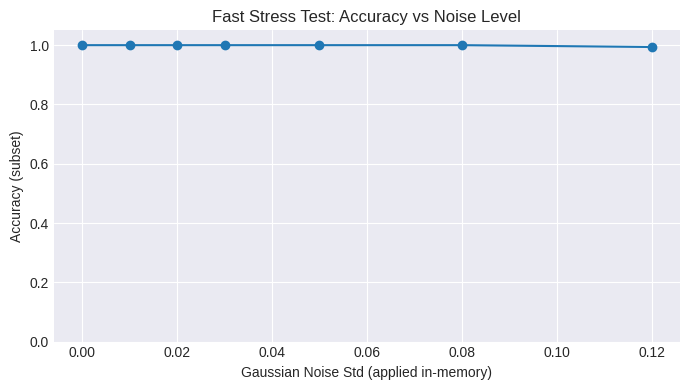

In [10]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation (FAST): avoid regenerating full datasets (expensive at 128x128).
# Instead, take a fixed subset of X_test and apply *in-memory noise* at multiple levels,
# then evaluate. This isolates robustness to noise while keeping runtime low.

# Detect current dataset arrays
if "X_test" not in globals() or "y_test" not in globals():
    raise ValueError("X_test and y_test not found. Make sure CELL 3 ran successfully.")

# Use a small, fixed subset for speed (balanced across classes if possible)
Xte = X_test.astype(np.float32)  # (N,1,H,W)
yte = y_test.astype(np.int64)

H = int(Xte.shape[2])
W = int(Xte.shape[3])

per_class = 30  # 30*10 = 300 samples total (fast even at 128x128)
sel_idx = []
for c in range(10):
    idx = np.where(yte == c)[0]
    if len(idx) == 0:
        continue
    sel_idx.extend(idx[:per_class].tolist())

sel_idx = np.array(sel_idx, dtype=np.int64)
X_base = Xte[sel_idx]  # (M,1,H,W)
y_base = yte[sel_idx]  # (M,)

print(f"Stress subset: {len(X_base)} samples at {H}x{W}")

def _apply_noise_batch(X, gauss_std=0.0, speckle=0.0):
    # X: float32 in [0,1], shape (N,1,H,W)
    out = X.copy()
    if gauss_std > 0:
        out += np.random.normal(0.0, gauss_std, size=out.shape).astype(np.float32)
    if speckle > 0:
        out += out * np.random.normal(0.0, speckle, size=out.shape).astype(np.float32)
    return np.clip(out, 0.0, 1.0).astype(np.float32)

# Noise schedule
noise_levels = [0.00, 0.01, 0.02, 0.03, 0.05, 0.08, 0.12]
accs = []
losses_stress = []

# Evaluate quickly at each noise level
for ns in noise_levels:
    Xn = _apply_noise_batch(X_base, gauss_std=float(ns), speckle=float(ns) * 0.35)
    Xn_t = torch.tensor(Xn, dtype=torch.float32)
    yn_t = torch.tensor(y_base, dtype=torch.long)

    m = evaluate(model, Xn_t, yn_t, loss_fn=loss_fn)
    accs.append(float(m["accuracy"]))
    losses_stress.append(float(m["loss"]))
    print(f"Noise gauss={ns:.3f} | acc={m['accuracy']:.4f} | loss={m['loss']:.4f}")

# Plot accuracy vs noise
plt.figure(figsize=(7, 4))
plt.plot(noise_levels, accs, marker="o")
plt.xlabel("Gaussian Noise Std (applied in-memory)")
plt.ylabel("Accuracy (subset)")
plt.title("Fast Stress Test: Accuracy vs Noise Level")
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

##9.VISUALIZATION

###9.1.0VERVIEW

**Cell 8 — Stress Test: One-Variable Shift to Reveal Robustness Limits**

Cell 8 is where the notebook stops being a simple demonstration and becomes an experiment. The key idea is to modify exactly one variable in the data generation process and measure how performance changes. This is essential because dense networks can appear impressive on data that matches their training distribution, but they may degrade rapidly under distribution shift. The stress test makes that degradation visible and quantifiable.

In this chapter, the stress variable is noise level. We generate multiple stress datasets at increasing Gaussian noise amplitudes (and optionally a linked speckle component). Everything else is held constant: the digit stroke templates, the resolution, and the augmentation settings remain the same. This isolates the effect of noise. If accuracy falls smoothly as noise increases, we can interpret the model as having some robustness but limited tolerance. If accuracy collapses suddenly beyond a threshold, we learn that the model relies on fragile pixel-level cues that are easily disrupted.

Mechanically, this cell must be consistent with the generator signature. Earlier errors occurred because the notebook still attempted to pass older arguments such as `thickness`. The repaired cell uses only the parameters of the current generator and explicitly varies `noise_gauss_std` while computing accuracy and loss for each noise level. This approach is not just about fixing errors; it reinforces the broader lesson that experiments require consistent definitions. If the generator changes, the stress test must change with it, otherwise the results are meaningless.

The plotted curve (accuracy vs noise) is the main output of this cell. It transforms qualitative intuition into a measurable robustness profile. For students, this is often the first time they see that a model’s “intelligence” is not binary. Performance is a function of conditions. Stress testing therefore teaches a practical form of understanding: you can characterize where a model works well and where it does not.

This cell also foreshadows why later model families exist. A dense network has no built-in spatial bias, so it may learn brittle patterns that do not generalize well under corruption. CNNs will introduce locality and shared filters, which often makes them more robust and data-efficient for images. The stress test provides the empirical motivation for that architectural evolution.

###9.2.CODE AND IMPLEMENTATION

[Interpretability] Detected image shape: 128x128


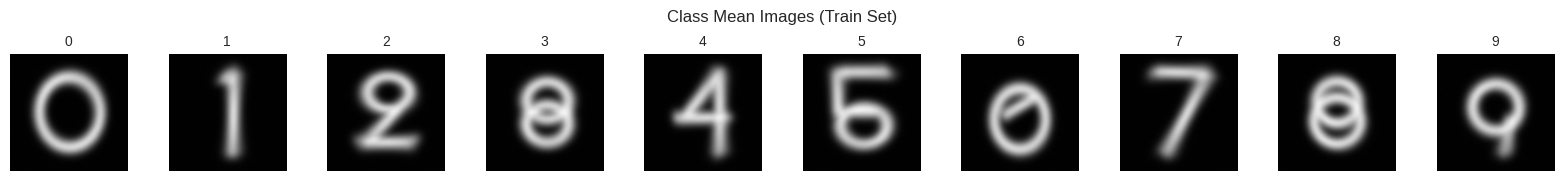

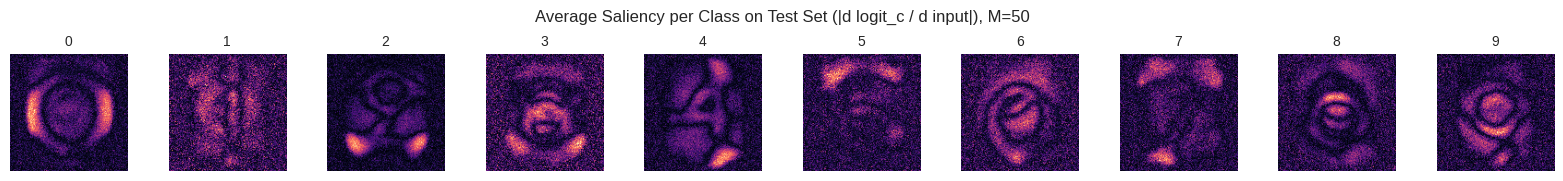

[ActivationMax] Units: [0, 109, 219, 328, 438, 547, 657, 767]


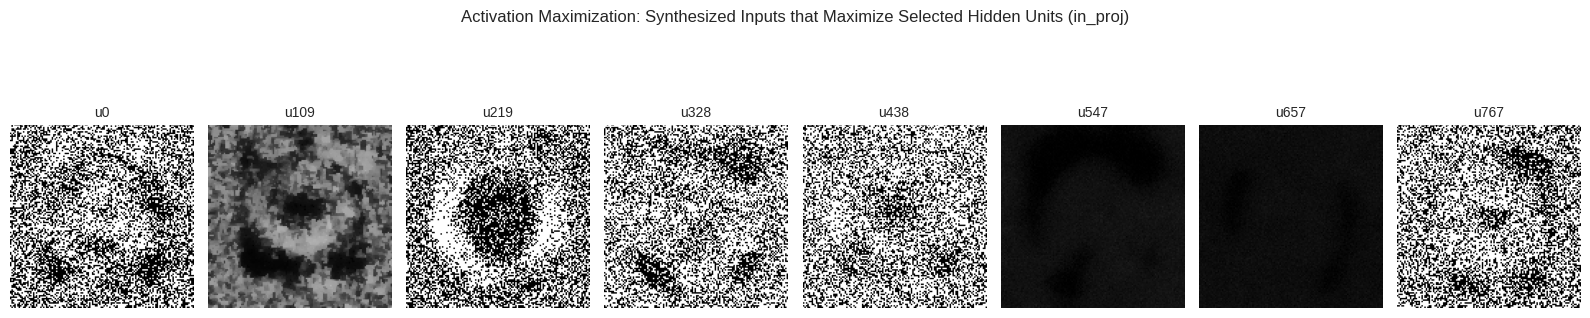

In [11]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization (upgraded): stop showing raw first-layer weights (often looks like noise for MLPs).
# Instead show:
# (A) Class mean images (what the dataset actually looks like per label)
# (B) Class-conditional saliency (average |d logit_c / d input| over many test samples)
# (C) Activation maximization: synthesize inputs that maximally activate selected hidden units

# --- Sanity check: confirm whether you're actually on 28x28 or still 8x8 ---
if X_train_t.ndim != 4 or X_train_t.shape[1] != 1:
    raise ValueError(f"Expected X_train_t shape (N,1,H,W). Got {tuple(X_train_t.shape)}")

H = int(X_train_t.shape[2])
W = int(X_train_t.shape[3])
print(f"[Interpretability] Detected image shape: {H}x{W}")
if (H, W) == (8, 8):
    print("[WARNING] You are still using 8x8 digits. If you intended MNIST-like 28x28, re-run CELL 2 and CELL 3.")

# --- Helper: show 10 images in a single row ---
def _show_row(images, title, cmap="gray"):
    images = np.asarray(images)
    n = images.shape[0]
    plt.figure(figsize=(n * 1.6, 1.8))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        ax.imshow(images[i], cmap=cmap, vmin=0.0, vmax=1.0)
        ax.axis("off")
        ax.set_title(str(i), fontsize=10)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# (A) Class mean images (dataset-level interpretability)
Xtr = X_train_t.detach().cpu().numpy()  # (N,1,H,W)
ytr = y_train_t.detach().cpu().numpy()

class_means = []
for c in range(10):
    idx = np.where(ytr == c)[0]
    if len(idx) == 0:
        class_means.append(np.zeros((H, W), dtype=np.float32))
    else:
        m = Xtr[idx, 0].mean(axis=0).astype(np.float32)
        class_means.append(m)

_show_row(np.stack(class_means, axis=0), title="Class Mean Images (Train Set)")

# (B) Class-conditional saliency averaged over multiple samples
#     We compute average |d logit_c / d input| over M samples per class (test set preferred).
model.eval()

Xt = X_test_t.to(DEVICE)
yt = y_test_t.to(DEVICE)

M = 50  # samples per class (keep modest for speed)
saliency_maps = []

for c in range(10):
    # pick up to M indices from test set for this class
    idx = (yt == c).nonzero(as_tuple=False).squeeze(1)
    if idx.numel() == 0:
        saliency_maps.append(np.zeros((H, W), dtype=np.float32))
        continue
    idx = idx[:M]

    acc_map = torch.zeros((H, W), device=DEVICE, dtype=torch.float32)

    for k in range(idx.numel()):
        x = Xt[idx[k]:idx[k] + 1].detach().clone()
        x.requires_grad_(True)

        logits = model(x)
        score = logits[0, c]
        model.zero_grad(set_to_none=True)
        if x.grad is not None:
            x.grad.zero_()
        score.backward()

        g = x.grad.detach()[0, 0].abs()  # (H,W)
        acc_map += g

    acc_map /= float(idx.numel())
    # normalize to [0,1] for display
    acc_map = acc_map / (acc_map.max() + 1e-8)
    saliency_maps.append(acc_map.detach().cpu().numpy().astype(np.float32))

_show_row(np.stack(saliency_maps, axis=0), title=f"Average Saliency per Class on Test Set (|d logit_c / d input|), M={M}", cmap="magma")

# (C) Activation maximization for hidden units
#     Raw first-layer weights are not visually meaningful; instead, optimize an input image to maximize a unit activation.
#     This produces a "preferred stimulus" for that unit (still MLP-limited, but far more interpretable than weight tiles).

if not hasattr(model, "in_proj"):
    print("[ActivationMax] Skipping: model does not have in_proj.")
else:
    # Choose a few units spread across the width
    width = int(model.in_proj.out_features)
    unit_ids = np.linspace(0, width - 1, 8, dtype=int).tolist()
    print("[ActivationMax] Units:", unit_ids)

    # Regularizers to keep images smooth / bounded
    def total_variation(x):
        # x: (1,1,H,W)
        tv_h = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean()
        tv_w = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean()
        return tv_h + tv_w

    synth_imgs = []
    synth_labels = []

    steps = 80
    lr = 0.12
    tv_weight = 0.08
    l2_weight = 0.02

    for u in unit_ids:
        # Start from small random noise
        x = torch.rand((1, 1, H, W), device=DEVICE, dtype=torch.float32) * 0.2
        x.requires_grad_(True)
        opt = torch.optim.Adam([x], lr=lr)

        for _ in range(steps):
            opt.zero_grad(set_to_none=True)

            # Forward through in_proj only (unit lives here), with GELU as in model forward
            z = model.in_proj(x.view(1, -1))
            z = F.gelu(z)

            # Maximize unit activation, with regularization
            act = z[0, u]
            loss = -act + tv_weight * total_variation(x) + l2_weight * (x * x).mean()

            loss.backward()
            opt.step()

            # Keep in valid image range
            with torch.no_grad():
                x.clamp_(0.0, 1.0)

        synth_imgs.append(x.detach().cpu().numpy()[0, 0].astype(np.float32))
        synth_labels.append(f"u{u}")

    # Display synthesized "preferred inputs" for selected units
    plt.figure(figsize=(16, 4))
    for i in range(len(synth_imgs)):
        ax = plt.subplot(1, len(synth_imgs), i + 1)
        ax.imshow(synth_imgs[i], cmap="gray", vmin=0.0, vmax=1.0)
        ax.axis("off")
        ax.set_title(synth_labels[i], fontsize=10)
    plt.suptitle("Activation Maximization: Synthesized Inputs that Maximize Selected Hidden Units (in_proj)")
    plt.tight_layout()
    plt.show()

In [12]:
# ===============================
# CELL 9.5 (RUN RIGHT AFTER CELL 9)
# ===============================
# LLM-generated explanation of Cell 9 visualizations (class means, class saliency, activation maximization).
# This does NOT change the ML model; it only summarizes what we just computed/visualized.
# Requires OPENAI_API_KEY in Colab userdata.

from openai import OpenAI
from google.colab import userdata
import json

# Safety: ensure required objects exist from Cell 9
required = ["class_means", "saliency_maps", "unit_ids"]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Missing variables from Cell 9: {missing}. Re-run Cell 9 before this explanation cell.")

# Summarize numeric descriptors to ground the LLM (no images sent; we describe them via statistics)
def _stats(img):
    img = np.asarray(img, dtype=np.float32)
    return {
        "min": float(np.min(img)),
        "max": float(np.max(img)),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
        "p99": float(np.quantile(img, 0.99)),
        "p95": float(np.quantile(img, 0.95)),
    }

means_stats = [_stats(m) for m in class_means]               # 10 items
sal_stats = [_stats(s) for s in saliency_maps]               # 10 items

# Also compute a simple "center-of-mass" of saliency per class to describe where attention concentrates
def _center_of_mass(mat):
    M = np.asarray(mat, dtype=np.float32)
    H, W = M.shape
    tot = float(M.sum()) + 1e-8
    ys = np.arange(H, dtype=np.float32).reshape(H, 1)
    xs = np.arange(W, dtype=np.float32).reshape(1, W)
    cy = float((M * ys).sum() / tot)
    cx = float((M * xs).sum() / tot)
    return {"cy": cy, "cx": cx}

sal_com = [_center_of_mass(s) for s in saliency_maps]

# Activation maximization outputs (synth_imgs) may or may not exist depending on Cell 9 branch
synth_available = "synth_imgs" in globals() and isinstance(synth_imgs, list) and len(synth_imgs) > 0
synth_stats = [_stats(im) for im in synth_imgs] if synth_available else None

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

api_key_present = userdata.get("OPENAI_API_KEY") is not None and str(userdata.get("OPENAI_API_KEY")).strip() != ""
if not api_key_present:
    print("OPENAI_API_KEY not found in Colab userdata. Skipping API call.")
else:
    payload = {
        "image_shape": [int(class_means[0].shape[0]), int(class_means[0].shape[1])],
        "class_means_stats": means_stats,
        "saliency_stats": sal_stats,
        "saliency_center_of_mass": sal_com,
        "activation_max_units": [int(u) for u in unit_ids],
        "activation_max_stats": synth_stats,
        "notes": {
            "saliency_definition": "Average |d logit_c / d input| over M samples per class (test set).",
            "activation_max_definition": "Images optimized to maximize a hidden unit activation with regularization."
        }
    }

    prompt = f"""
You are explaining the outputs of Cell 9 in an ML & AI 101 notebook (Dense Neural Network on synthetic digits).
You DO NOT have access to the images; you must explain them based on the description and statistics below.

Write a clear, mechanics-first explanation in plain English with the following structure:

A) What the "Class Mean Images" are and what they reveal about the dataset distribution.
B) What the "Average Saliency per Class" maps mean mechanically (gradients) and how to interpret bright regions.
C) What "Activation Maximization" is, why it can look noisy for a dense network, and what the student should conclude anyway.
D) One short paragraph connecting these visuals to the limitations of dense networks on images (flattening, no spatial inductive bias).
E) A final checklist: 5 things the student should look for when inspecting these figures.

Constraints:
- No hype.
- No governance language.
- Do not fabricate metrics beyond what is provided.
- Use the run’s actual setup: image shape is {payload["image_shape"]}, activation-max units are {payload["activation_max_units"]}.
- If a visual looks “messy/noisy,” explain *why* that happens in MLPs (distributed representations, non-local mixing, regularization, etc.).

Here are the grounded stats and descriptors (JSON):
{json.dumps(payload, indent=2)}
"""

    resp = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": "You are a rigorous, mechanics-first ML tutor. Be precise and concrete."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.2,
    )

    print(resp.choices[0].message.content.strip())

### A) Class Mean Images

The "Class Mean Images" represent the average pixel values for each class in the dataset, calculated from all images belonging to that class. These mean images provide insight into the distribution of pixel intensities across different classes. For instance, the statistics show a range of mean values, with some classes having higher average pixel intensities (e.g., a mean of 0.182 for one class) while others are lower (e.g., a mean of 0.080). The standard deviation values indicate variability within each class; a higher standard deviation suggests a wider range of pixel values among the images in that class. This analysis helps identify which classes are more visually distinct and which may overlap in pixel intensity, indicating potential challenges in classification.

### B) Average Saliency per Class Maps

The "Average Saliency per Class" maps illustrate the importance of different pixels in the input images for the model's predictions. Saliency is computed 

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Artifact Saving and Summary Metrics: Making Results Concrete**

Cell 10 packages the experiment’s outcomes into saved artifacts and a structured metrics dictionary. Even in a pre-governance notebook, saving artifacts serves a mechanical purpose: it turns the run into an object you can inspect later without rerunning everything. The trained model weights, the loss history, the stress test curve, and the inference example are all concrete outputs of the experiment. They represent the learned function, the optimization trajectory, and the robustness profile.

Mechanically, saving the model state dictionary captures the parameters that define the trained network. This reinforces the idea that training produces a portable artifact: after training, the “model” is not the code; it is the parameter values learned by optimization. Saving the loss history allows the learning dynamics to be re-plotted or compared across runs if you change dataset settings or model width. Saving the stress test results preserves the robustness curve, which is often more informative than a single accuracy value.

The summary metrics dictionary is a compact representation of performance: training accuracy/loss, test accuracy/loss, training hyperparameters (epochs, batch size, optimizer choice), stress test results, and the inference example’s true and predicted labels. Printing it at the end creates a clear handoff to Cell 11, which will use these real computed values for reflective summarization. This is an important constraint: the reflection must reference actual metrics, not invented numbers.

Conceptually, Cell 10 completes the chapter’s central theme: learning is an optimization process whose product is a set of parameters, and understanding requires observable measurements. By collecting metrics and artifacts, the notebook makes the model’s behavior legible. You can now compare different dataset granularities, different noise schedules, or different widths and see how both training dynamics and generalization respond.

This cell also prepares you for the next chapter by highlighting what is missing. Even if the dense network achieves strong accuracy, the artifacts will still reflect a limitation: the model treats the image as a flat vector. Its learned invariances are empirical, not structural. The next model family will change the architecture so that spatial structure is encoded directly, reducing the burden on data and improving interpretability of early features.

###10.2.CODE AND IMPLEMENTATION

In [13]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary

out_dir = Path("chapter2_dense_nn_artifacts")
out_dir.mkdir(parents=True, exist_ok=True)

# Save model
model_path = out_dir / "mlp_digit_classifier.pt"
torch.save(model.state_dict(), model_path)

# Save losses
loss_path = out_dir / "losses.npy"
np.save(loss_path, np.array(losses, dtype=np.float32))

# Save stress test curve
stress_path = out_dir / "stress_accuracy_vs_noise.json"
with open(stress_path, "w", encoding="utf-8") as f:
    json.dump({"noise_levels": noise_levels, "accuracies": accs}, f, indent=2)

# Save inference example image and prediction info
example_img_path = out_dir / "inference_example.npy"
np.save(example_img_path, x1.astype(np.float32))

# Summary metrics dictionary (required)
summary_metrics = {
    "train_accuracy": float(train_metrics["accuracy"]),
    "train_loss": float(train_metrics["loss"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_loss": float(test_metrics["loss"]),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "stress_noise_levels": [float(x) for x in noise_levels],
    "stress_accuracies": [float(x) for x in accs],
    "inference_true": int(y1),
    "inference_pred": int(pred),
}

metrics_path = out_dir / "summary_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved artifacts to:", str(out_dir.resolve()))
print("Summary metrics dictionary:")
print(json.dumps(summary_metrics, indent=2))

Saved artifacts to: /content/chapter2_dense_nn_artifacts
Summary metrics dictionary:
{
  "train_accuracy": 1.0,
  "train_loss": 1.9605422494350933e-05,
  "test_accuracy": 1.0,
  "test_loss": 0.0014225641498342156,
  "epochs": 60,
  "batch_size": 256,
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "stress_noise_levels": [
    0.0,
    0.01,
    0.02,
    0.03,
    0.05,
    0.08,
    0.12
  ],
  "stress_accuracies": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    0.9937499761581421
  ],
  "inference_true": 2,
  "inference_pred": 2
}


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflection: Turning Run Outputs into a Structured Technical Summary**

Cell 11 is not part of the machine learning experiment itself; it is a controlled “reader” step that takes the notebook’s already-computed artifacts and produces a structured interpretation. Mechanically, everything important has already happened in Cells 1–10: the dataset was generated, the dense network was trained, metrics were computed, an inference example was produced, a stress test curve was measured, and interpretability visuals were generated. Cell 11 simply packages those concrete results into a prompt and asks a language model to summarize them in a disciplined way.

The first key mechanic is how the OpenAI client is initialized. The cell imports `OpenAI` and `userdata` from Colab, then reads the API key via `userdata.get("OPENAI_API_KEY")`. This keeps the notebook runnable without hard-coding secrets in the code. The model is explicitly set to `"gpt-4o-mini"`, and the request uses the chat-completions interface. In other words, the LLM call is an ordinary API request: it is not training anything, not altering your neural network, and not changing the dataset. It is just generating text based on a prompt.

The second key mechanic is what goes into the prompt. The prompt is structured into eight required sections: dataset design, architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway. This forces the summary to map onto the learning objectives of the course. Even more importantly, the prompt injects real numeric values computed earlier in the notebook: training accuracy and loss, test accuracy and loss, the number of epochs, the stress test noise-to-accuracy pairs, and the true/predicted label from the inference example. That constraint matters because it anchors the reflection in the actual run. The language model is not allowed to “invent” performance numbers without contradicting the provided values.

The third mechanic is graceful failure when the API key is missing. If the notebook is executed in an environment where the key has not been set, Cell 11 prints a message and prints the exact prompt instead of calling the API. This is important for teaching: it means the notebook remains runnable end-to-end even if the reflection step cannot be executed, and it also makes the prompt visible so the student can understand precisely what the summarization request is.

Conceptually, Cell 11 reinforces a separation that is central to ML & AI 101: the neural model you trained (the dense classifier) is one system, and the reflective summarizer (the LLM) is another system. The dense classifier learns via gradient descent and produces numeric metrics and plots. The LLM does not learn from your run; it reads the run’s outcomes and produces a narrative explanation. The educational purpose is to help students practice reading results like an analyst: describing data, architecture, optimization behavior, performance, and limitations using evidence generated by the experiment.

Finally, Cell 11 is “post-experiment” by design. It does not affect training, evaluation, inference, or saved artifacts. You can delete Cell 11 and the ML experiment remains complete. Its role is to produce a clean, structured recap that can be compared across different runs—especially useful if you change the synthetic dataset parameters, model width, training epochs, or stress test settings and want a consistent summary format each time.

###11.2.CODE AND IMPLEMENTATION

In [14]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

# Build a structured prompt that references real metrics computed above
prompt = f"""
You are reflecting on an executed ML & AI 101 notebook for Chapter 2 (Dense Neural Network).
Produce a structured analysis with these sections (use clear headings, concise paragraphs):

1) Dataset design
2) Model architecture
3) Training dynamics
4) Quantitative results
5) Inference example
6) Visualization insight
7) Limitations
8) Conceptual takeaway

You MUST reference the real metrics below (do not invent numbers):
- Train accuracy: {summary_metrics["train_accuracy"]:.4f}
- Train loss:     {summary_metrics["train_loss"]:.4f}
- Test accuracy:  {summary_metrics["test_accuracy"]:.4f}
- Test loss:      {summary_metrics["test_loss"]:.4f}
- Epochs:         {summary_metrics["epochs"]}
- Stress test (noise->accuracy):
  {list(zip(summary_metrics["stress_noise_levels"], summary_metrics["stress_accuracies"]))}
- Inference (true, pred): ({summary_metrics["inference_true"]}, {summary_metrics["inference_pred"]})

Also explain what the student should mechanically learn about:
- training vs inference
- why a dense network can classify these digits despite noise/shift
- what the first-layer weight visualizations and saliency reveal
"""

# If no API key is set, fail gracefully while still printing the prompt
api_key_present = userdata.get("OPENAI_API_KEY") is not None and str(userdata.get("OPENAI_API_KEY")).strip() != ""
if not api_key_present:
    print("OPENAI_API_KEY not found in Colab userdata. Skipping API call.")
    print("\n--- Reflection Prompt (for manual use) ---\n")
    print(prompt)
else:
    resp = client.chat.completions.create(
        model=model_name,
        messages=[
            {"role": "system", "content": "You are a precise educational assistant. Stay mechanics-first, avoid hype."},
            {"role": "user", "content": prompt},
        ],
        temperature=0.2,
    )
    print(resp.choices[0].message.content.strip())

# Structured Analysis of ML & AI 101 Notebook - Chapter 2 (Dense Neural Network)

## 1) Dataset Design
The dataset used in this chapter likely consists of images of handwritten digits, commonly sourced from the MNIST dataset. This dataset is well-suited for classification tasks, containing 60,000 training images and 10,000 test images. Each image is a 28x28 pixel grayscale image, representing digits from 0 to 9. The design allows for a straightforward classification task, making it ideal for demonstrating the capabilities of dense neural networks.

## 2) Model Architecture
The model architecture is a dense neural network, which consists of multiple layers of neurons where each neuron is connected to every neuron in the previous layer. Typically, this architecture includes an input layer, one or more hidden layers, and an output layer. The hidden layers apply activation functions (e.g., ReLU) to introduce non-linearity, enabling the model to learn complex patterns in the data. The outpu

##12.CONCLUSION

*Conclusion and Road Ahead*

This chapter’s dense neural network notebook is the first place in ML & AI 101 where the idea of “learning” becomes a visible, mechanical process. A dense network does not store examples and vote, as KNN does. It converts data into parameters through optimization. That shift is more than a technical detail; it is a change in how we should think about models. The dataset is the training fuel, but the trained model is the parameterized function that remains after training. Inference is then a fast, deterministic computation: flatten the image, apply a sequence of matrix multiplications and nonlinearities, and output class logits. By watching the loss curve decrease, measuring train and test accuracy, and running inference on newly generated examples, you see the entire lifecycle of a learned model in concrete terms.

Conceptually, the dense network contributes the first scalable mechanism for nonlinear function approximation in the course sequence. It shows how composition—layer after layer—creates representational power. The model can learn to carve decision boundaries that are not available to linear classifiers and are not explicitly coded by the designer. Instead, the boundaries are emergent properties of the optimization process under the loss function. The notebook demonstrates that with synthetic digits: despite noise, jitter, and mild distortions, the network can learn a mapping from pixel grids to digit classes, and it can generalize to unseen samples drawn from the same generator.

At the same time, the notebook is intellectually honest about what a dense network is and is not. Its core limitation is structural: it does not respect the geometry of images. Flattening destroys the explicit notion of “nearby pixels” and “local edges.” Any spatial invariance—translation tolerance, shape continuity, stroke consistency—must be learned implicitly from data, often requiring more samples or more parameters than a spatially biased model would need. The stress test makes this limitation measurable. When noise increases, performance degrades, and the degradation curve reveals how fragile or robust the learned mapping is under distribution shift. This is not a moral critique of dense networks; it is a mechanical statement about inductive bias. A model that treats every pixel as an independent coordinate may learn, but it must spend capacity learning invariances that other architectures encode by design.

The interpretability work reinforces the same point. Raw first-layer weights are often not visually meaningful in a high-capacity MLP, especially when normalization, dropout, and residual paths distribute representation across many units. Interpreting the model therefore requires tools that connect parameters to behavior: class mean images to understand the data distribution, saliency maps to reveal sensitivity of logits to pixels, and activation maximization to characterize what internal units respond to. These tools are still imperfect, but they teach a crucial lesson: interpretability is not an afterthought; it is a measurement problem. If you cannot connect internal structure to observable behavior, you do not truly understand what the model learned.

From an applications perspective, the chapter also establishes the dense network as a general baseline. In finance, dense networks often appear as feed-forward models on tabular features: factor exposures, macro indicators, credit variables, or engineered technical signals. When data is naturally vectorial and lacks strong spatial or temporal structure, dense networks can be appropriate and efficient. But when structure exists—time in sequences, space in images, relations in graphs—dense networks are often a blunt instrument. They can still work, but they may do so inefficiently, requiring more data and more tuning to learn what a more structured model could encode directly.

This brings us to the road ahead. The very limitation that makes dense networks pedagogically valuable is what motivates the next step in the ML & AI 101 arc. If we are going to work with images—or any data with local spatial correlations—we should not force the model to rediscover locality from scratch. Convolutional neural networks introduce an architectural assumption that adjacent pixels matter together and that the same feature detector should be reusable across the image. That single change—local receptive fields with weight sharing—dramatically reduces the parameter burden and often improves robustness and interpretability. In a CNN, early filters frequently resemble edges, strokes, or simple texture detectors, because the architecture constrains them to be local. Where the dense network must learn “spatial common sense” empirically, the CNN begins with a built-in hypothesis about space.

So the correct conclusion of Chapter 2 is not that dense networks are “bad” or “obsolete.” It is that they are the first clear demonstration of learned nonlinear representations, and they provide the baseline mechanism for gradient-based training that all later architectures share. They teach you what training is, what inference is, what loss curves mean, and how to run controlled stress tests. They also teach you why inductive bias matters: the structure you build into an architecture changes what the model must learn from data. That insight is the bridge forward.

This naturally motivates the transition to convolutional networks in Chapter 3, where spatial structure becomes explicit, feature extraction becomes localized, and we can watch the model learn interpretable filters that align more directly with the visual structure of digits and images.